## Indicino Attrition Analysis

### Understanding Employee Attrition and Key Drivers

### Project Overview

Employee attrition is a major challenge impacting organizational performance and cost

This project analyzes employee data from Indicino to:
- Identify key drivers of attrition
- Predict high-risk employee groups
- Provide actionable HR recommendations

### Objectives

1. Identify root causes of attrition  
2. Determine high-risk job roles  
3. Analyze age-based retention  
4. Evaluate manager impact  
5. Assess performance & reward structure  

In [2]:
#Importing Neccessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
#Importing the dataset
df = pd.read_csv("../data/raw/Indicino project.xlsx - Attrition_data.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Data Cleaning

In [4]:
#Dataframe overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13   JobInvolvement           1470 non-null   object
 14  JobLevel                

In [5]:
#Clean column names
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   object
 14  JobLevel                

In [6]:
#Convert Target variable to binary
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [7]:
#Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
#Check for missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Exploratory Data Analysis(EDA)

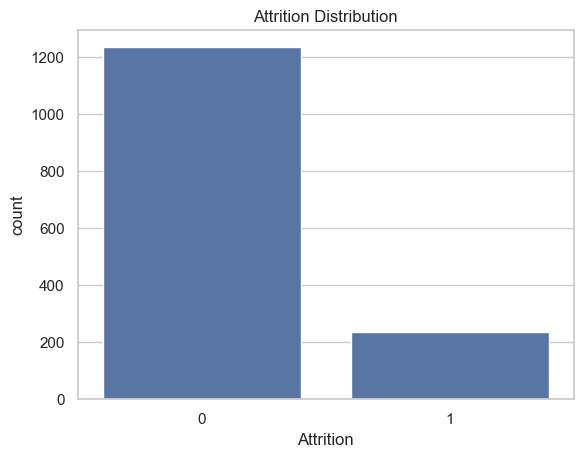

In [9]:
#Attrition distribution
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

In [10]:
#Groupby comparison
df.groupby('Attrition').mean(numeric_only=True).T

Attrition,0,1
Age,37.561233,33.607595
DailyRate,812.504461,750.362869
DistanceFromHome,8.915653,10.632911
Education,2.927007,2.839662
EmployeeCount,1.000000,1.000000
EmployeeNumber,1027.656123,1010.345992
EnvironmentSatisfaction,2.771290,2.464135
HourlyRate,65.952149,65.573840
JobLevel,2.145985,1.637131
JobSatisfaction,2.778589,2.468354


### Insight:
Employees who left tend to:
- Be younger
- Earn less
- Have lower job satisfaction
- Have shorter tenure

In [11]:
#Correlation matrix
corr = df.corr(numeric_only=True)
corr['Attrition'].sort_values(ascending=False)

Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHours                    NaN
Name: Attrition, dtype: float64

In [12]:
#Remove NaN values from the correlation matrix
corr = corr.drop(['EmployeeCount', 'StandardHours'], axis=1).drop(['EmployeeCount', 'StandardHours'], axis=0)

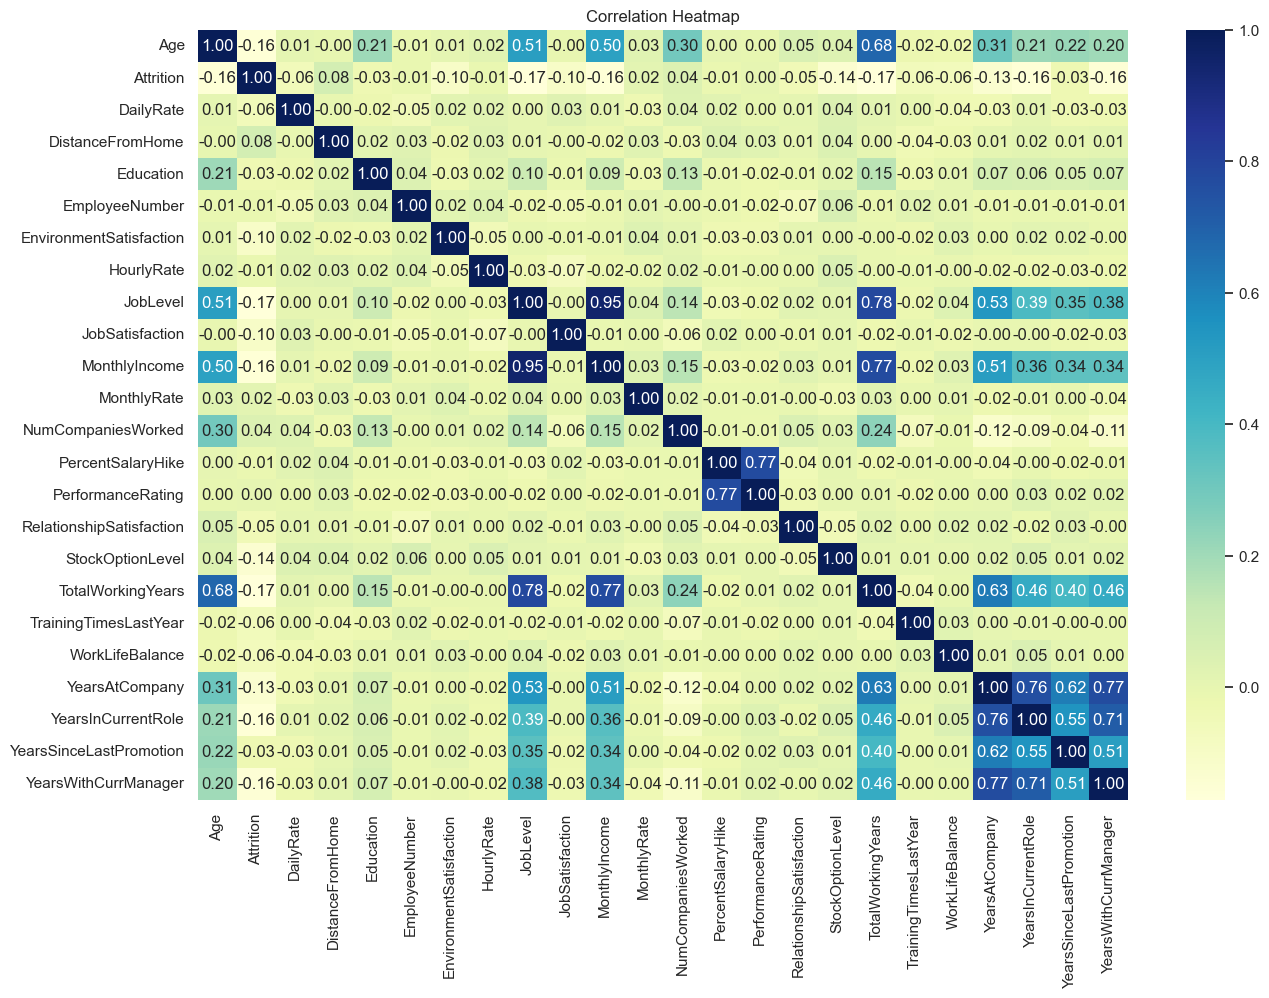

In [13]:
#Correlation Heatmap 
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Insights:
- Attrition is negatively correlated with income, age, job level, and experience
- Also possitively correlated with distance from home, number of companies worked and monthly rate(very low)
- Performance rating has little impact on attrition
- Correlation values are relatively low(around ±0.17 max), this means that;
    - No single factor explains attrition
    - Its a combination of multiple factors

### Key Driver Analysis

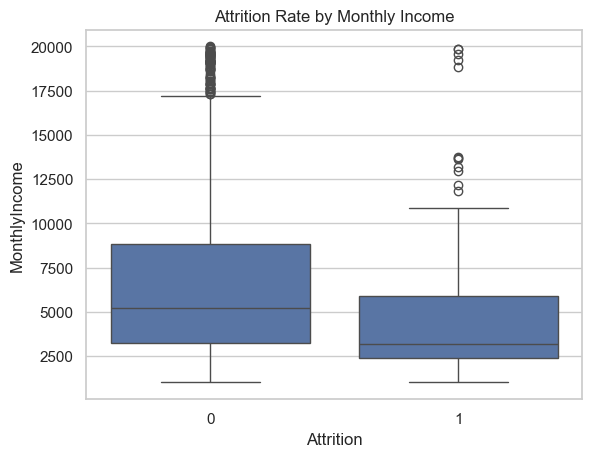

In [14]:
#Attrition Rate by Monthly Income
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Attrition Rate by Monthly Income')
plt.show()

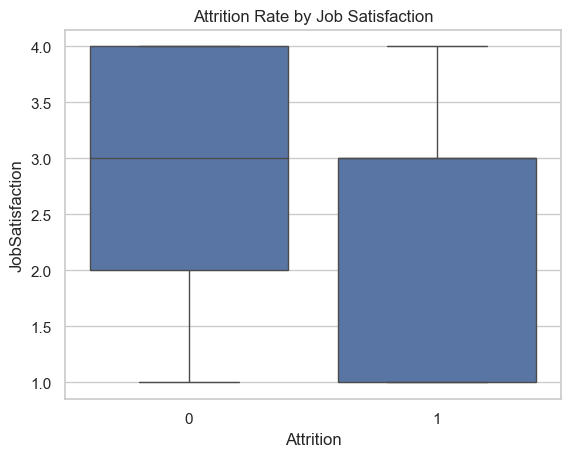

In [15]:
#Attrition Rate by Job Satisfaction
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df)
plt.title('Attrition Rate by Job Satisfaction')
plt.show()

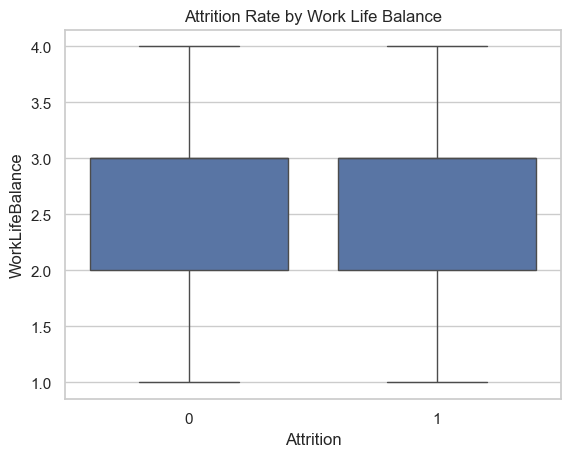

In [16]:
#Attrition Rate by Work Life Balance
sns.boxplot(x='Attrition', y='WorkLifeBalance', data=df)
plt.title('Attrition Rate by Work Life Balance')
plt.show()

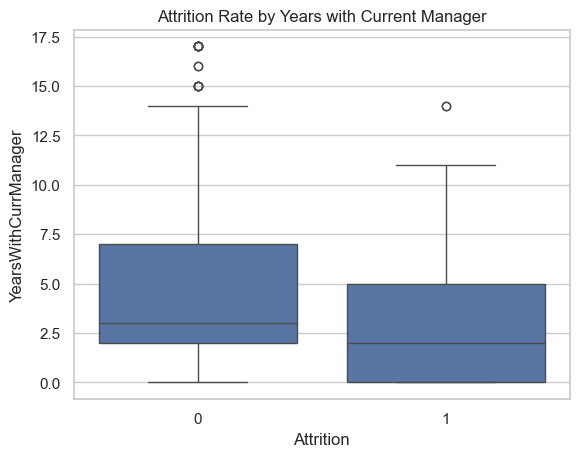

Attrition
0    4.367397
1    2.852321
Name: YearsWithCurrManager, dtype: float64

In [17]:
#Attrition Rate by Managers Impact
sns.boxplot(x='Attrition', y='YearsWithCurrManager', data=df)
plt.title('Attrition Rate by Years with Current Manager')
plt.show()

df.groupby('Attrition')['YearsWithCurrManager'].mean()

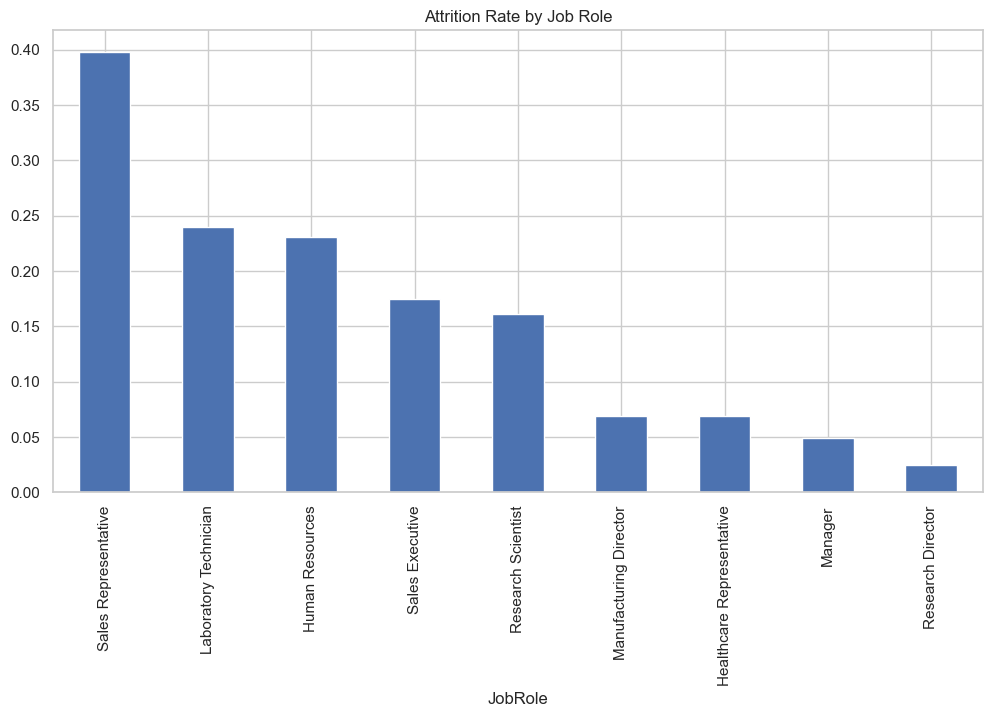

In [18]:
#Attrition Rate by Job Role
attrition_role = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False)

attrition_role.plot(kind='bar', figsize=(12, 6))
plt.title('Attrition Rate by Job Role')
plt.show()

## Insight:
Certain roles show significantly higher attrition, indicating workload or growth issues.

/var/folders/f7/bbf0__h1527f_plv7xn_vfk40000gn/T/ipykernel_27589/3225687160.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df.groupby('AgeBand')['Attrition'].mean()


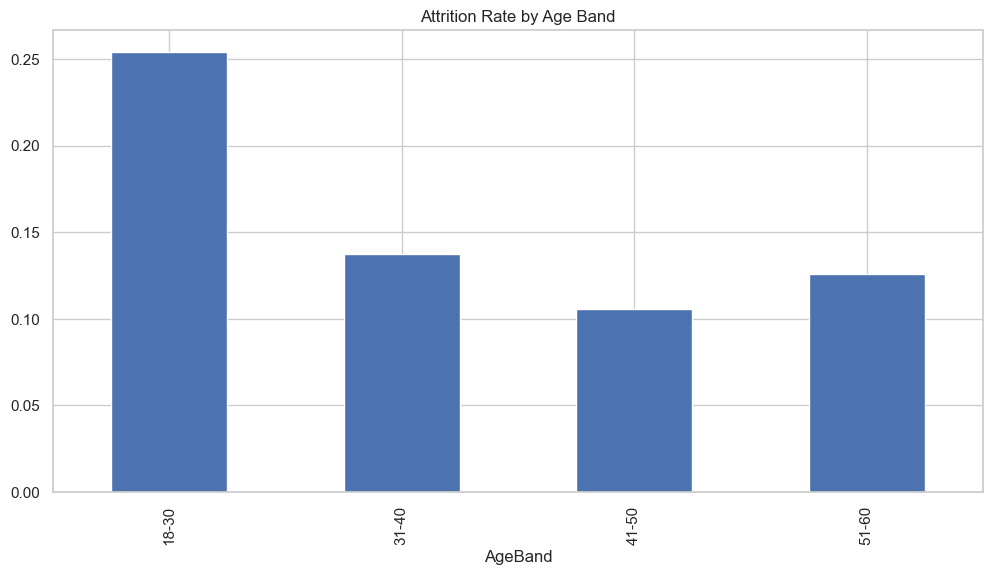

In [19]:
#Attrition Rate by Age Band
df['AgeBand'] = pd.cut(df['Age'], 
                       bins=[18, 30, 40, 50, 60], 
                       labels=['18-30', '31-40', '41-50', '51-60'])
age_attrition = df.groupby('AgeBand')['Attrition'].mean()

age_attrition.plot(kind='bar', figsize=(12, 6))
plt.title('Attrition Rate by Age Band')
plt.show()

## Insight:
Younger employees have higher attrition rates, indicating early-career instability.

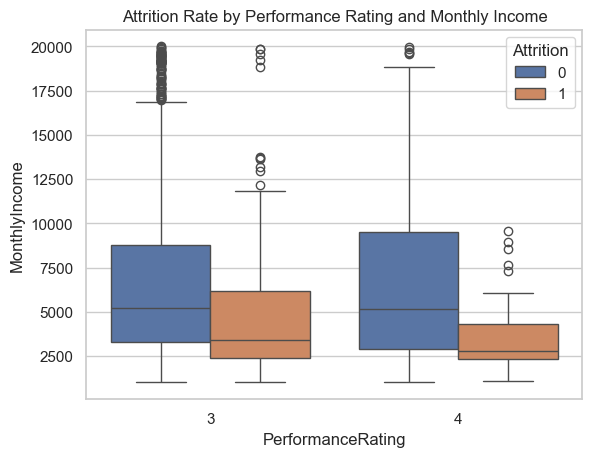

In [20]:
#Attrition Rate by Performance Rating and Monthly Income
sns.boxplot(x='PerformanceRating', y='MonthlyIncome', hue='Attrition', data=df)
plt.title('Attrition Rate by Performance Rating and Monthly Income')
plt.show()

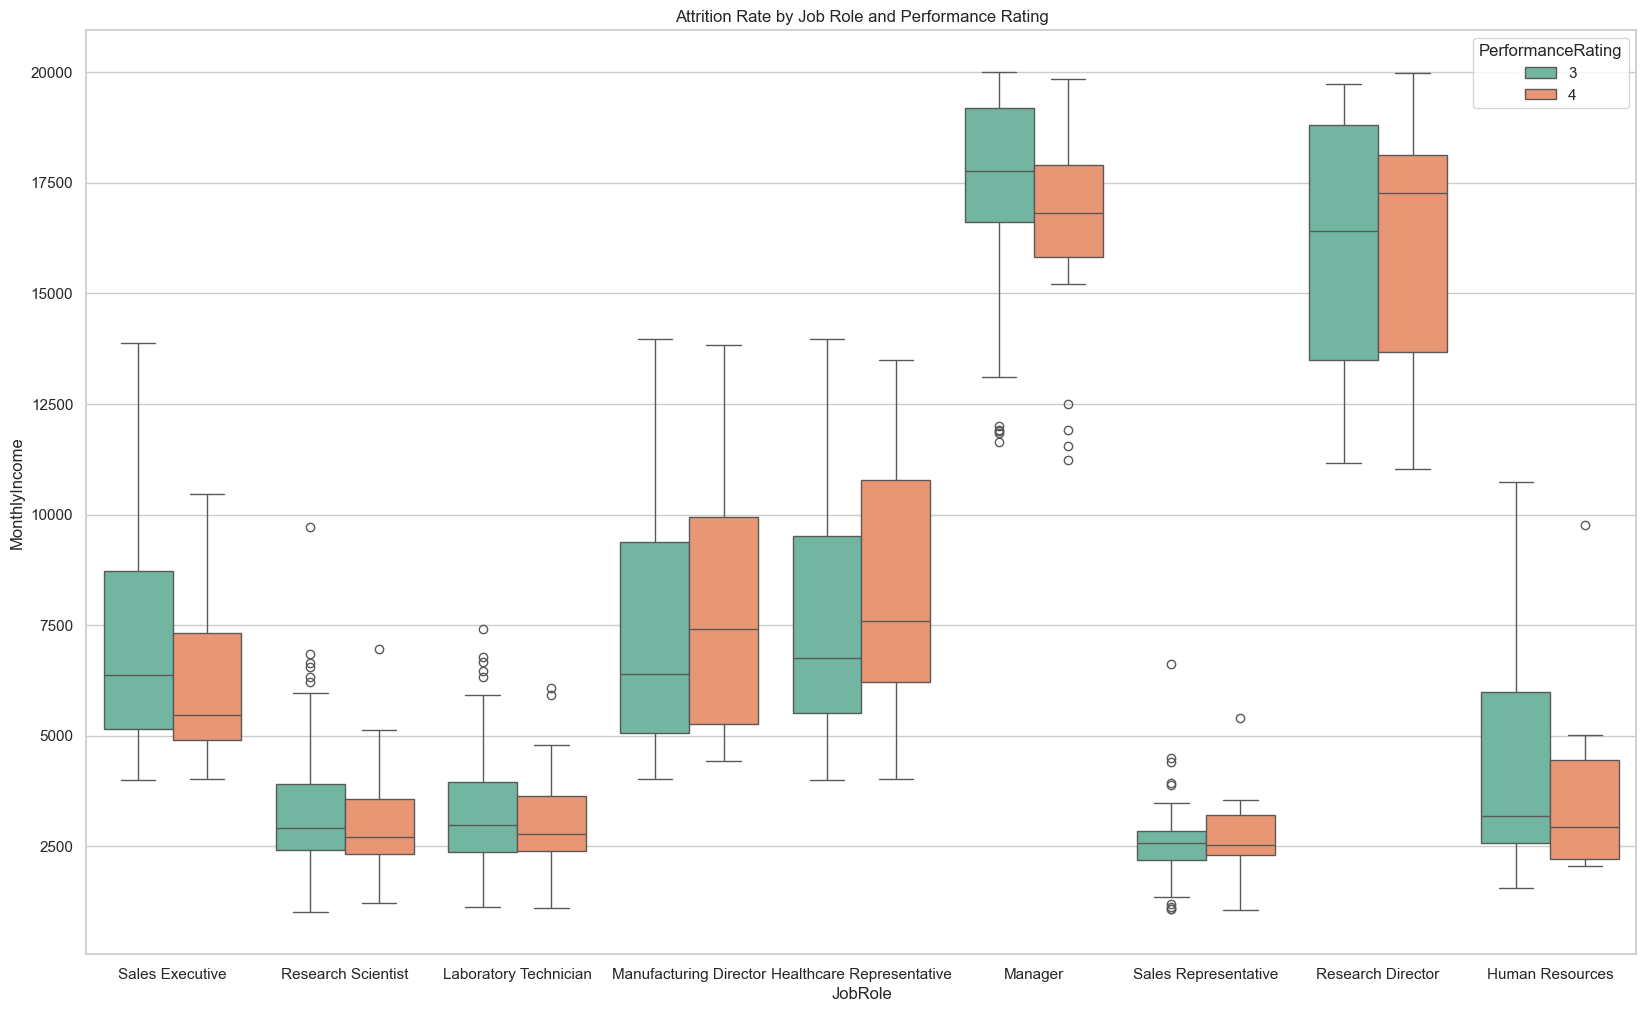

In [21]:
#Attrition Rate by Job Role and Performance Rating
plt.figure(figsize=(20, 12))
sns.boxplot(x='JobRole', y='MonthlyIncome', hue='PerformanceRating', data=df, palette='Set2')
plt.title('Attrition Rate by Job Role and Performance Rating')
plt.show()

## Insights:
Attrition is not driven by performance, this suggests that;
- High performers are not necessarily rewarded better
- Weak performance-reward alignment

## PREDICTIVE MODELING

In [22]:
#Modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

MonthlyIncome           0.067637
Age                     0.054908
TotalWorkingYears       0.050267
EmployeeNumber          0.047023
DailyRate               0.046349
HourlyRate              0.044618
MonthlyRate             0.044361
YearsAtCompany          0.044125
DistanceFromHome        0.041218
YearsWithCurrManager    0.035602
dtype: float64

### Key Predictors:
- Monthly Income
- Job Level
- Years at Company
- Age
- Manager Tenure

### Findings

- Attrition is higher among younger, lower-level employees  
- Compensation plays a significant role in retention  
- Manager relationship impacts employee stability  
- Job satisfaction and work environment influence attrition  
- Performance is not strongly linked to retention  

### Recommendations

1. Improve compensation for entry-level roles  
2. Strengthen onboarding and early employee engagement  
3. Train managers to improve staff retention within the team  
4. Align rewards with performance  
5. Introduce work-life balance initiatives  

## Conclusion

This analysis demonstrates that attrition at Indicino is driven by a combination of compensation, career stage, and employee experience factors.

By addressing these areas, the company can significantly improve retention and overall workforce performance.

In [23]:
# Model Evaluation

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8333333333333334
Precision: 0.8888888888888888
Recall: 0.14285714285714285
F1 Score: 0.24615384615384617
Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       238
           1       0.89      0.14      0.25        56

    accuracy                           0.83       294
   macro avg       0.86      0.57      0.58       294
weighted avg       0.84      0.83      0.78       294



### Model Evaluation Summary

Key findings
- The model acheived 85.7% accuracy score, indicating strong performance in predicting employees who remained in the company
- It only acheived 7% recall score, meaning it failed to identify most employees at risk of attrition
- The poor recall score is due to data class imbalance issue(employees who stayed significantly outnumbered those who resigned)
- Since the primary objective of this project is to identify employees likely to leave, recall is one important evaluation metric to measure that, hence the need for model improvement

In [28]:
# Save the cleaned dataset
df.to_csv("../data/processed/cleaned_data.csv", index=False)

# Save the model
import joblib
joblib.dump(model, '../models/rf_baseline.pkl')


['../models/rf_baseline.pkl']